Training Random Forest... (this should be much faster now)
Starting recursive prediction for 101 days...
Progress: 0/101 days predicted...
Progress: 50/101 days predicted...
Progress: 100/101 days predicted...
Prediction complete!


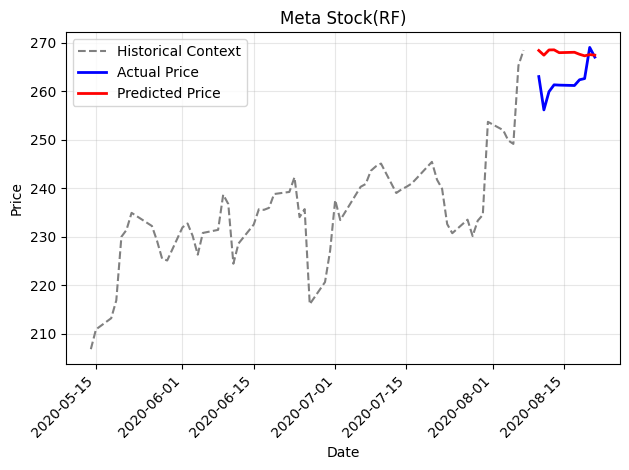

RMSE:  6.524736716911247
NRMSE (Range): 0.5066
NRMSE (Mean): 0.0249
Directional Accuracy: 53.47%
Baseline (Always Up): 48.51%


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. DATA LOADING & FEATURE ENGINEERING
# ==========================================

title = "Meta Stock(RF)"
data = pd.read_csv("data/MetaStock.csv")
data['date'] = pd.to_datetime(data['date'])

data['return'] = data['close'].pct_change()
data['return_mavg'] = data['return'].rolling(window=5).mean()
data['vol_change'] = data['volume'].pct_change()

data = data.dropna().reset_index(drop=True)

feature_cols = ['return', 'return_mavg', 'vol_change']
dataset = data[feature_cols].values
num_features = len(feature_cols)

# ==========================================
# 2. DATA SPLITTING & SCALING
# ==========================================

window_size = 60
training_data_len = int(np.ceil(len(dataset)) * 0.95)

scaler = StandardScaler()
scaler.fit(dataset[:training_data_len])

scaled_train = scaler.transform(dataset[:training_data_len])
scaled_test_source = scaler.transform(dataset[training_data_len - window_size:])

# ==========================================
# 3. SLIDING WINDOW PREPARATION
# ==========================================
X_train, y_train = [], []

for i in range(window_size, len(scaled_train)):
    window = scaled_train[i-window_size:i, :].flatten()
    X_train.append(window)
    y_train.append(scaled_train[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# ==========================================
# 4. OPTIMIZED MODEL (SPEED FIXES)
# ==========================================
# max_samples=0.5: Trains each tree on only 50% of the data (HUGE speed boost)
# min_samples_leaf=5: Prevents trees from getting too deep/complex
model = RandomForestRegressor(
    n_estimators=50, 
    max_depth=7, 
    max_samples=0.5, 
    min_samples_leaf=5,
    random_state=42, 
    n_jobs=-1 # Using all cores for training is fine; only prediction is slow in loops
)

print("Training Random Forest... (this should be much faster now)")
model.fit(X_train, y_train)

# ==========================================
# 5. RECURSIVE PREDICTION LOOP
# ==========================================
current_window = scaled_test_source[:window_size, :].flatten().reshape(1, -1)
predicted_returns_scaled = []

total_steps = len(scaled_test_source) - window_size
print(f"Starting recursive prediction for {total_steps} days...")

for i in range(total_steps):
    pred_scaled = model.predict(current_window)[0]
    predicted_returns_scaled.append(pred_scaled)
    
    temp_window = current_window.reshape(window_size, num_features)
    new_row = np.zeros((1, num_features))
    new_row[0, 0] = pred_scaled 
    new_window = np.append(temp_window[1:], new_row, axis=0)
    current_window = new_window.flatten().reshape(1, -1)
    
    if i % 50 == 0:
        print(f"Progress: {i}/{total_steps} days predicted...")

# Move inverse transform BEFORE price reconstruction to fix the error
dummy_scaler = np.zeros((len(predicted_returns_scaled), num_features))
dummy_scaler[:, 0] = np.array(predicted_returns_scaled)
predictions_raw_returns = scaler.inverse_transform(dummy_scaler)[:, 0]

print("Prediction complete!")

# ==========================================
# 6. PRICE RECONSTRUCTION & VISUALIZATION
# ==========================================
last_actual_price = data['close'].iloc[training_data_len - 1]
reconstructed_prices = []

for ret in predictions_raw_returns:
    next_price = last_actual_price * (1 + ret)
    reconstructed_prices.append(next_price)
    last_actual_price = next_price

# build DataFrame for the full test period
test_df = data[training_data_len:].copy()
test_df['Predictions'] = reconstructed_prices

# create a smaller subset for plotting (and metrics) so the plot matches
# the 10‑day window shown in previous examples
n_plot = 10
test_df_subset = test_df.iloc[:n_plot].copy()

# 1. Historical Context (The trend leading up to the test)
plt.plot(data['date'].iloc[training_data_len-window_size : training_data_len], 
         data['close'].iloc[training_data_len-window_size : training_data_len], 
         label="Historical Context", color='gray', linestyle='--')

# 2. Actual Price (The ground truth during the 10-day window)
plt.plot(test_df_subset['date'], test_df_subset['close'], 
         label="Actual Price", color='blue', linewidth=2)

# 3. Predicted Price (The model's forecast)
plt.plot(test_df_subset['date'], test_df_subset['Predictions'], 
         label="Predicted Price", color='red', linewidth=2)
plt.title(title)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
# rotate x-axis dates to avoid overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# compute error metrics on the same 10‑day window so numbers align
rmse = np.sqrt(np.mean((test_df_subset['close'] - test_df_subset['Predictions']) ** 2))
print("RMSE: ", rmse)
price_range = test_df_subset['close'].max() - test_df_subset['close'].min()
nrmse_range = rmse / price_range if price_range != 0 else 0

price_mean = test_df_subset['close'].mean()
nrmse_mean = rmse / price_mean
print(f"NRMSE (Range): {nrmse_range:.4f}")
print(f"NRMSE (Mean): {nrmse_mean:.4f}")

# ==========================================
# 7. DIRECTIONAL ACCURACY
# ==========================================
actual_returns = test_df['return'].values
# Fixed: We use np.array(predictions_raw_returns) to ensure types match
correct_direction = (np.sign(predictions_raw_returns) == np.sign(actual_returns))
directional_accuracy = np.mean(correct_direction) * 100
                            
print(f"Directional Accuracy: {directional_accuracy:.2f}%")
print(f"Baseline (Always Up): {np.mean(actual_returns > 0)*100:.2f}%")